Primer Parcial

Estudiante: Chelsea Melany Espinoza Cava

Carrera: Ing. de Sistemas

El conjunto de datos de viviendas de Ames contiene 82 variables explicativas que describen (casi) todos los aspectos de las viviendas residenciales en Ames, Iowa, con el objetivo de predecir el precio de venta.

In [45]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import seaborn as sns

In [46]:
df_train = pd.read_csv('train.csv') 
df_test = pd.read_csv('test.csv')
print(f"Alquiler de Bicicletas")
print(f"Dimensiones: {df_train.shape}")
df_train.head()

Alquiler de Bicicletas
Dimensiones: (10886, 12)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [47]:
# Verificar nulos
print("\n--- Conteo de Nulos por Columna ---")
nulos = df_train.isnull().sum()
print(nulos[nulos > 0])

print(f"\nTotal general de nulos: {df_train.isnull().sum().sum()}")


--- Conteo de Nulos por Columna ---
Series([], dtype: int64)

Total general de nulos: 0


In [48]:
for df in [df_train, df_test]:
    df['datetime'] = pd.to_datetime(df['datetime'])
    df['hour'] = df['datetime'].dt.hour
    df['dayofweek'] = df['datetime'].dt.dayofweek
    # Borramos datetime y las columnas que causan trampa (casual/registered)
    # Nota: El test no suele traer casual/registered, así que usamos errors='ignore'
    df.drop(['datetime', 'casual', 'registered'], axis=1, inplace=True, errors='ignore')



In [49]:
scaler = StandardScaler()

# Separamos el target (count) del train antes de escalar
y_train = df_train['count'].values
X_train_raw = df_train.drop('count', axis=1)

# El test no tiene 'count', así que lo tomamos todo
X_test_raw = df_test

# Entrenamos el scaler con el TRAIN y transformamos ambos
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print(f"X_train (Entrenamiento): {X_train.shape}")
print(f"X_test (Testeo): {X_test.shape}")

X_train (Entrenamiento): (10886, 10)
X_test (Testeo): (6493, 10)


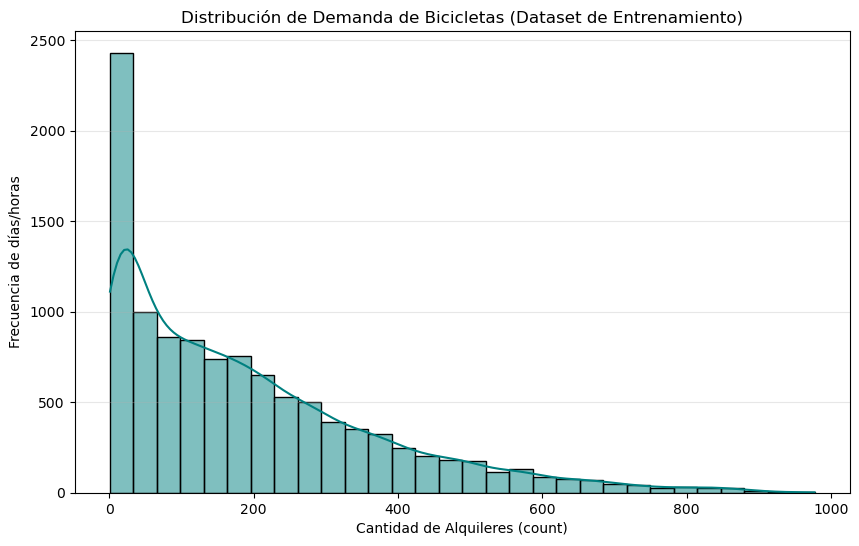

In [50]:
plt.figure(figsize=(10, 6))
sns.histplot(df_train['count'], kde=True, color='teal', bins=30)

# 2. Estética de la gráfica
plt.title('Distribución de Demanda de Bicicletas (Dataset de Entrenamiento)')
plt.xlabel('Cantidad de Alquileres (count)')
plt.ylabel('Frecuencia de días/horas')
plt.grid(axis='y', alpha=0.3)